# PCA Preprocessing for Drug Response Dataset (GPU Accelerated)

This notebook reduces gene expression features using PyTorch GPU-accelerated PCA.

**Output:**
- `data/processed/pca_reduced/` - PCA-transformed parquet files
- `data/processed/pca_reduced/pca_model.pkl` - Fitted PCA model for inference
- `data/processed/pca_reduced/metadata.json` - Column info and variance explained
- `data/processed/pca_reduced/scree_plot.png` - Variance analysis plot

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
import glob
import json
from tqdm import tqdm
import pyarrow.parquet as pq
import joblib
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print("\nLibraries loaded successfully!")

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.6 GB

Libraries loaded successfully!


## Configuration

In [15]:
# Input/Output paths
DATA_DIR = Path("data/processed/final_dataset_parquet")  # Original data
MODEL_DIR = Path("data/processed/pca_model")  # PCA model, scree plot, metadata
TRANSFORMED_DIR = Path("data/processed/pca_transformed")  # Transformed parquet files

# Number of PCA components to keep
N_COMPONENTS = 1000

# Sampling ratio for fitting (1 = every file, 4 = every 4th file = 25%)
SAMPLE_EVERY_N = 4

# Create output directories
MODEL_DIR.mkdir(parents=True, exist_ok=True)
TRANSFORMED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input directory: {DATA_DIR}")
print(f"Model output: {MODEL_DIR}")
print(f"Transformed data: {TRANSFORMED_DIR}")
print(f"PCA components: {N_COMPONENTS}")
print(f"Sample ratio: 1/{SAMPLE_EVERY_N} ({100/SAMPLE_EVERY_N:.0f}% of data for fitting)")

Input directory: data\processed\final_dataset_parquet
Model output: data\processed\pca_model
Transformed data: data\processed\pca_transformed
PCA components: 1000
Sample ratio: 1/4 (25% of data for fitting)


## Step 1: Load and Inspect Dataset Structure

In [16]:
# Find all parquet files
part_files = sorted(glob.glob(str(DATA_DIR / "part_*.parquet")))
print(f"Found {len(part_files)} parquet files")

# Read schema from first file
schema = pq.read_schema(part_files[0])
all_columns = schema.names
print(f"Total columns: {len(all_columns):,}")

Found 118 parquet files
Total columns: 41,148


In [17]:
# Identify metadata columns by EXACT known names
known_metadata_cols = {
    'DRUG_NAME', 'DRUG_ID', 'IC50', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE',
    'CELL_LINE_NAME', 'CELL_LINE_ID', 'COSMIC_ID', 'SANGER_ID', 'SAMPLE_ID',
    'TCGA_DESC', 'TISSUE', 'TISSUE_TYPE', 'CANCER_TYPE', 'CANCER_TYPE_DETAIL',
    'MODEL_ID', 'MODEL_NAME', 'DATASET', 'SOURCE', 'INDEX'
}

# Load a sample to check column types
sample_df = pd.read_parquet(part_files[0])

metadata_cols = []
gene_cols = []
string_gene_cols = []

for col in all_columns:
    if col in known_metadata_cols:
        metadata_cols.append(col)
    else:
        dtype = sample_df[col].dtype
        
        if pd.api.types.is_string_dtype(dtype) or dtype == object:
            try:
                sample_vals = sample_df[col].dropna().head(10)
                if len(sample_vals) > 0:
                    pd.to_numeric(sample_vals)
                    gene_cols.append(col)
                    string_gene_cols.append(col)
                else:
                    metadata_cols.append(col)
            except (ValueError, TypeError):
                metadata_cols.append(col)
        elif pd.api.types.is_numeric_dtype(dtype):
            gene_cols.append(col)
        else:
            metadata_cols.append(col)

del sample_df

print(f"\nColumn breakdown:")
print(f"  Metadata columns: {len(metadata_cols)}")
print(f"  Gene expression columns: {len(gene_cols):,}")
print(f"  (of which stored as strings: {len(string_gene_cols):,})")


Column breakdown:
  Metadata columns: 250
  Gene expression columns: 40,898
  (of which stored as strings: 40,898)


In [18]:
def load_and_convert_genes(filepath, gene_cols, string_gene_cols):
    """Load gene columns and convert strings to float32."""
    chunk = pd.read_parquet(filepath, columns=gene_cols)
    
    for col in string_gene_cols:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors='coerce')
    
    chunk = chunk.astype(np.float32)
    
    if chunk.isna().any().any():
        chunk = chunk.fillna(0)
    
    return chunk

print("Helper function defined.")

Helper function defined.


## Step 2: Fit PCA using PyTorch GPU

We fit on a sample (~25% of data) to fit in GPU memory, then transform ALL data.

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from functools import partial

def load_single_file(filepath, gene_cols, string_gene_cols):
    chunk = pd.read_parquet(filepath, columns=gene_cols)
    for col in string_gene_cols:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors='coerce')
    chunk = chunk.astype(np.float32)
    if chunk.isna().any().any():
        chunk = chunk.fillna(0)
    return chunk.values

print(f"Fitting PCA with {N_COMPONENTS} components using PyTorch GPU...")
print(f"Processing {len(gene_cols):,} gene features")

sample_files = part_files[::SAMPLE_EVERY_N]
print(f"Using {len(sample_files)} files ({len(sample_files)/len(part_files)*100:.0f}%) for fitting")
print(f"Loading with 3 parallel threads...")

load_func = partial(load_single_file, gene_cols=gene_cols, string_gene_cols=string_gene_cols)

# Use ThreadPoolExecutor instead of ProcessPoolExecutor
with ThreadPoolExecutor(max_workers=3) as executor:
    chunks = list(tqdm(executor.map(load_func, sample_files), 
                       total=len(sample_files), desc="Loading sample data"))

X_sample = np.vstack(chunks)
del chunks
print(f"\nSample shape: {X_sample.shape}")
print(f"Sample memory: {X_sample.nbytes / 1e9:.2f} GB")

Fitting PCA with 1000 components using PyTorch GPU...
Processing 40,898 gene features
Using 30 files (25%) for fitting
Loading with 3 parallel threads...


Loading sample data:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
# Compute mean for centering (required for PCA)
X_mean = X_sample.mean(axis=0, keepdims=True)
X_centered = X_sample - X_mean
del X_sample

# Move to GPU
print("Moving data to GPU...")
X_tensor = torch.tensor(X_centered, dtype=torch.float32).cuda()
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
del X_centered

In [ ]:
# Compute PCA using low-rank SVD (fast on GPU!)
print(f"Computing PCA on GPU (this should be fast)...")
U, S, V = torch.pca_lowrank(X_tensor, q=N_COMPONENTS, niter=2)

# Extract components
pca_components = V.cpu().numpy()  # Shape: (n_features, n_components)
singular_values = S.cpu().numpy()

# Compute explained variance ratio
total_var = (X_tensor ** 2).sum().item() / (X_tensor.shape[0] - 1)
explained_variance = (singular_values ** 2) / (X_tensor.shape[0] - 1)
explained_variance_ratio = explained_variance / total_var
variance_explained = explained_variance_ratio.sum()

# Clean up GPU memory
del X_tensor, U, S, V
torch.cuda.empty_cache()

# Flatten mean for transformations
X_mean = X_mean.flatten()

print(f"\n✓ PCA fitted successfully!")
print(f"  Variance explained by {N_COMPONENTS} components: {variance_explained:.2%}")
print(f"  GPU memory freed")

## Step 3: Scree Plot

NameError: name 'MODEL_DIR' is not defined

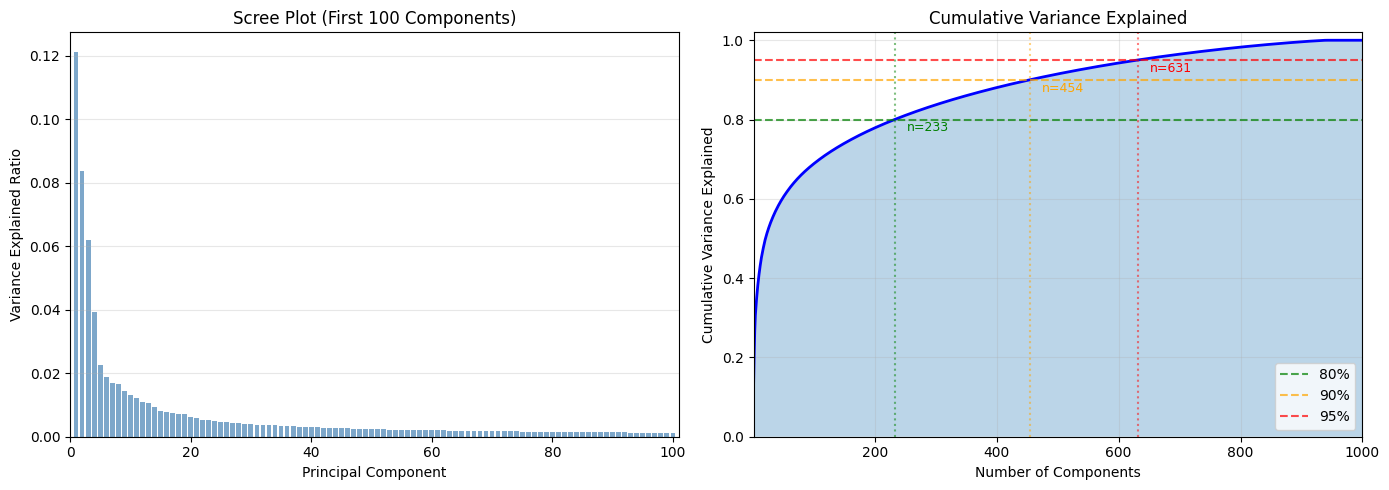

In [13]:
cumulative_var = np.cumsum(explained_variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual variance (first 100 components)
ax1 = axes[0]
n_show = min(100, N_COMPONENTS)
ax1.bar(range(1, n_show + 1), explained_variance_ratio[:n_show], alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained Ratio')
ax1.set_title(f'Scree Plot (First {n_show} Components)')
ax1.set_xlim(0, n_show + 1)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Cumulative variance
ax2 = axes[1]
ax2.plot(range(1, N_COMPONENTS + 1), cumulative_var, 'b-', linewidth=2)
ax2.fill_between(range(1, N_COMPONENTS + 1), cumulative_var, alpha=0.3)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')

# Add threshold lines
thresholds = [0.80, 0.90, 0.95]
colors = ['green', 'orange', 'red']
for thresh, color in zip(thresholds, colors):
    ax2.axhline(y=thresh, color=color, linestyle='--', alpha=0.7, label=f'{thresh:.0%}')
    crossed = np.where(cumulative_var >= thresh)[0]
    if len(crossed) > 0:
        n_for_thresh = crossed[0] + 1
        ax2.axvline(x=n_for_thresh, color=color, linestyle=':', alpha=0.5)
        ax2.annotate(f'n={n_for_thresh}', xy=(n_for_thresh, thresh), 
                    xytext=(n_for_thresh + N_COMPONENTS*0.02, thresh - 0.03),
                    fontsize=9, color=color)

ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)
ax2.set_xlim(1, N_COMPONENTS)
ax2.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(MODEL_DIR / "scree_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Scree plot saved to {MODEL_DIR / 'scree_plot.png'}")

In [ ]:
# Print variance thresholds
print("Components needed for variance thresholds:")
for thresh in [0.70, 0.80, 0.90, 0.95, 0.99]:
    crossed = np.where(cumulative_var >= thresh)[0]
    if len(crossed) > 0:
        print(f"  {thresh:.0%} variance: {crossed[0] + 1} components")
    else:
        print(f"  {thresh:.0%} variance: > {N_COMPONENTS} components")

## Step 4: Transform ALL Data and Save

Now we transform every row in the dataset using the fitted PCA components.

**Transformed files are saved to a separate directory to preserve original data.**

In [ ]:
pca_col_names = [f'PC_{i+1}' for i in range(N_COMPONENTS)]
total_rows = 0

print(f"Transforming ALL {len(part_files)} files...")
print(f"Saving to: {TRANSFORMED_DIR}")

for i, f in enumerate(tqdm(part_files, desc="Transforming", unit="file")):
    # Load full chunk
    chunk = pd.read_parquet(f)
    
    # Get and convert gene data
    gene_data = chunk[gene_cols].copy()
    for col in string_gene_cols:
        if col in gene_data.columns:
            gene_data[col] = pd.to_numeric(gene_data[col], errors='coerce')
    gene_data = gene_data.astype(np.float32).fillna(0).values
    
    # Transform: center and project
    centered = gene_data - X_mean
    reduced = centered @ pca_components  # Matrix multiply
    
    # Get metadata
    existing_meta = [c for c in metadata_cols if c in chunk.columns]
    metadata = chunk[existing_meta].copy()
    
    # Create output dataframe
    reduced_df = pd.DataFrame(reduced, columns=pca_col_names, dtype=np.float32)
    reduced_df = pd.concat([metadata.reset_index(drop=True), reduced_df], axis=1)
    
    # Save to TRANSFORMED_DIR (separate from original)
    output_path = TRANSFORMED_DIR / f"part_{i:05d}.parquet"
    reduced_df.to_parquet(output_path, index=False)
    
    total_rows += len(reduced_df)
    del chunk, gene_data, centered, reduced, metadata, reduced_df

print(f"\n✓ Transformed {total_rows:,} rows (100% of data)")
print(f"✓ Saved to: {TRANSFORMED_DIR}")

## Step 5: Save PCA Model and Metadata

In [ ]:
# Save PCA model (components and mean)
pca_model = {
    'components': pca_components,
    'mean': X_mean,
    'explained_variance_ratio': explained_variance_ratio,
    'n_components': N_COMPONENTS
}
model_path = MODEL_DIR / "pca_model.pkl"
joblib.dump(pca_model, model_path)
print(f"✓ PCA model saved to {model_path}")

# Save metadata
metadata_info = {
    "n_components": N_COMPONENTS,
    "variance_explained": float(variance_explained),
    "original_gene_columns": len(gene_cols),
    "string_gene_columns": len(string_gene_cols),
    "metadata_columns": metadata_cols,
    "pca_columns": pca_col_names,
    "total_rows": total_rows,
    "num_parts": len(part_files),
    "sample_ratio": f"1/{SAMPLE_EVERY_N}",
    "transformed_data_dir": str(TRANSFORMED_DIR)
}

metadata_path = MODEL_DIR / "metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata_info, f, indent=2)
print(f"✓ Metadata saved to {metadata_path}")

## Summary

In [12]:
print("=" * 60)
print("✓ PCA Preprocessing Complete!")
print("=" * 60)
print(f"\nModel directory: {MODEL_DIR}")
print(f"  - pca_model.pkl (for inference)")
print(f"  - metadata.json (column info)")
print(f"  - scree_plot.png (variance analysis)")
print(f"\nTransformed data: {TRANSFORMED_DIR}")
print(f"  - {len(part_files)} parquet files")
print(f"\nOriginal shape: ({total_rows:,}, {len(gene_cols):,})")
print(f"New shape: ({total_rows:,}, {len(metadata_cols) + N_COMPONENTS})")
print(f"Compression: {len(gene_cols):,} → {N_COMPONENTS} features")
print(f"Variance retained: {variance_explained:.1%}")

✓ PCA Preprocessing Complete!


NameError: name 'MODEL_DIR' is not defined

## Quick Verification

In [ ]:
# Load and preview the transformed data
transformed_files = sorted(glob.glob(str(TRANSFORMED_DIR / "part_*.parquet")))
sample_transformed = pd.read_parquet(transformed_files[0])

print(f"Transformed data shape: {sample_transformed.shape}")
print(f"\nColumns: {list(sample_transformed.columns[:15])}...")
print(f"\nFirst few rows:")
sample_transformed.head()